# AIT303 Assignment 1 — SVM Sentiment Models

**Author:** [Your Name]
**Date:** May 2026

Trains 4 SVM variants on the IMDB 50K dataset:
| # | Vectorizer | Preprocessing |
|---|-----------|--------------|
| 1 | CountVectorizer | Stemmed |
| 2 | CountVectorizer | Lemmatized |
| 3 | TfidfVectorizer | Stemmed |
| 4 | TfidfVectorizer | Lemmatized |

All models are evaluated with 5-fold Stratified K-Fold cross-validation and held-out test metrics.

---
### ⚡ Colab Instructions
If running on Google Colab:
1. Upload the `data_asg/` folder to your Google Drive (as `data_asg/`)
2. Set `COLAB = True` in the config cell below
3. Run all cells — the notebook will mount your Drive and read data from it

Heavy computation cells (5-fold cross-validation) are marked with **⚡ HEAVY** and may take 15-30 minutes each.


In [1]:
# ============================================
# CONFIGURATION
# ============================================
# Set to True when running on Google Colab
COLAB = True

# Data directory
if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/data_asg'
else:
    DATA_DIR = 'data_asg'

print(f"Running in {'COLAB' if COLAB else 'LOCAL'} mode")
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Running in COLAB mode
Data directory: /content/drive/MyDrive/data_asg


## 1. Setup & Imports

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Model
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, train_test_split

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Reproducibility
np.random.seed(42)

print("All imports loaded successfully")

All imports loaded successfully


## 2. Load Preprocessed Data

In [3]:
# Load preprocessed IMDB data
df = pd.read_csv(f'{DATA_DIR}/preprocessed_imdb.csv')
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
print(f"\nMissing values:\n{df.isnull().sum()}")
df.head(3)

DataFrame shape: (50000, 5)
Columns: ['review', 'sentiment', 'cleaned', 'stemmed', 'lemmatized']

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values:
review        0
sentiment     0
cleaned       0
stemmed       0
lemmatized    0
dtype: int64


,review,sentiment,cleaned,stemmed,lemmatized
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...,one reviewer mention watch oz episode hook rig...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,wonder littl product film techniqu unassum old...,wonderful little production film technique una...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...,think wonderful way spend time hot summer week...


In [4]:
# Encode sentiment: positive -> 1, negative -> 0
df['sentiment_encoded'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(f"Encoded distribution:\n{df['sentiment_encoded'].value_counts()}")

# Train/test split (80/20, stratified)
y = df['sentiment_encoded'].values

X_train_stemmed, X_test_stemmed, y_train, y_test = train_test_split(
    df['stemmed'].values, y, test_size=0.2, random_state=42, stratify=y
)
X_train_lemmatized, X_test_lemmatized, _, _ = train_test_split(
    df['lemmatized'].values, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set size: {len(X_train_stemmed)}")
print(f"Test set size: {len(X_test_stemmed)}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test class balance: {np.bincount(y_test)}")

Encoded distribution:
sentiment_encoded
1    25000
0    25000
Name: count, dtype: int64

Train set size: 40000
Test set size: 10000
Train class balance: [20000 20000]
Test class balance: [5000 5000]


## 3. Feature Extraction

### 3.1 CountVectorizer

In [5]:
# CountVectorizer with unigrams + bigrams
cv_stemmed = CountVectorizer(ngram_range=(1, 2))

# Fit on stemmed training data, transform both train and test
X_train_cv_stemmed = cv_stemmed.fit_transform(X_train_stemmed)
X_test_cv_stemmed = cv_stemmed.transform(X_test_stemmed)
print(f"CountVectorizer (stemmed): vocabulary size = {len(cv_stemmed.get_feature_names_out())}")
print(f"  Train: {X_train_cv_stemmed.shape}")
print(f"  Test:  {X_test_cv_stemmed.shape}")

# Separate vectorizer for lemmatized (different vocabulary)
cv_lemmatized = CountVectorizer(ngram_range=(1, 2))
X_train_cv_lemmatized = cv_lemmatized.fit_transform(X_train_lemmatized)
X_test_cv_lemmatized = cv_lemmatized.transform(X_test_lemmatized)
print(f"CountVectorizer (lemmatized): vocabulary size = {len(cv_lemmatized.get_feature_names_out())}")
print(f"  Train: {X_train_cv_lemmatized.shape}")
print(f"  Test:  {X_test_cv_lemmatized.shape}")


CountVectorizer (stemmed): vocabulary size = 2243876
  Train: (40000, 2243876)
  Test:  (10000, 2243876)
CountVectorizer (lemmatized): vocabulary size = 2343855
  Train: (40000, 2343855)
  Test:  (10000, 2343855)


### 3.2 TfidfVectorizer

In [6]:
# TfidfVectorizer with unigrams + bigrams
tv_stemmed = TfidfVectorizer(ngram_range=(1, 2))

# Fit on stemmed training data, transform both train and test
X_train_tfidf_stemmed = tv_stemmed.fit_transform(X_train_stemmed)
X_test_tfidf_stemmed = tv_stemmed.transform(X_test_stemmed)
print(f"TfidfVectorizer (stemmed): vocabulary size = {len(tv_stemmed.get_feature_names_out())}")
print(f"  Train: {X_train_tfidf_stemmed.shape}")
print(f"  Test:  {X_test_tfidf_stemmed.shape}")

tv_lemmatized = TfidfVectorizer(ngram_range=(1, 2))
X_train_tfidf_lemmatized = tv_lemmatized.fit_transform(X_train_lemmatized)
X_test_tfidf_lemmatized = tv_lemmatized.transform(X_test_lemmatized)
print(f"TfidfVectorizer (lemmatized): vocabulary size = {len(tv_lemmatized.get_feature_names_out())}")
print(f"  Train: {X_train_tfidf_lemmatized.shape}")
print(f"  Test:  {X_test_tfidf_lemmatized.shape}")


TfidfVectorizer (stemmed): vocabulary size = 2243876
  Train: (40000, 2243876)
  Test:  (10000, 2243876)
TfidfVectorizer (lemmatized): vocabulary size = 2343855
  Train: (40000, 2343855)
  Test:  (10000, 2343855)


## 4. Model Training

### 4.1 SVM + CountVectorizer (Direct on Pre-vectorized Data)

In [7]:
# LinearSVC trained directly on pre-vectorized CountVectorizer features
# NO pipeline — vectorization already done once in Section 3
from sklearn.svm import LinearSVC

svm_cv_stemmed = LinearSVC(C=1.0, random_state=42, max_iter=5000)
svm_cv_lemmatized = LinearSVC(C=1.0, random_state=42, max_iter=5000)
print("LinearSVC models for CountVectorizer features created (not yet fitted).")
print(f"  Model 1: CV + LinearSVC (stemmed) — features: {X_train_cv_stemmed.shape[1]}")
print(f"  Model 2: CV + LinearSVC (lemmatized) — features: {X_train_cv_lemmatized.shape[1]}")


LinearSVC models for CountVectorizer features created (not yet fitted).
  Model 1: CV + LinearSVC (stemmed) — features: 2243876
  Model 2: CV + LinearSVC (lemmatized) — features: 2343855


### 4.2 SVM + TfidfVectorizer (Direct on Pre-vectorized Data)

In [8]:
# LinearSVC trained directly on pre-vectorized TfidfVectorizer features
svm_tfidf_stemmed = LinearSVC(C=1.0, random_state=42, max_iter=5000)
svm_tfidf_lemmatized = LinearSVC(C=1.0, random_state=42, max_iter=5000)
print("LinearSVC models for TfidfVectorizer features created (not yet fitted).")
print(f"  Model 3: TFIDF + LinearSVC (stemmed) — features: {X_train_tfidf_stemmed.shape[1]}")
print(f"  Model 4: TFIDF + LinearSVC (lemmatized) — features: {X_train_tfidf_lemmatized.shape[1]}")


LinearSVC models for TfidfVectorizer features created (not yet fitted).
  Model 3: TFIDF + LinearSVC (stemmed) — features: 2243876
  Model 4: TFIDF + LinearSVC (lemmatized) — features: 2343855


## 5. Cross-Validation & Evaluation

### 5.1 CountVectorizer — 5-fold Cross-Validation
⚡ **HEAVY COMPUTATION** — This cell runs 5-fold CV for 2 SVM models on 40K training samples with ~100K features each.
Expected: ~15-30 minutes on CPU.

In [9]:
# 5-fold Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate on pre-vectorized CountVectorizer features (NO re-vectorization)
print("Running 5-fold CV for CountVectorizer + LinearSVC (stemmed)...")
scores_cv_stemmed = cross_validate(
    LinearSVC(C=1.0, random_state=42, max_iter=5000), X_train_cv_stemmed, y_train,
    cv=cv, scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    return_train_score=False, n_jobs=-1
)
print("  Stemmed CV complete.")

print("Running 5-fold CV for CountVectorizer + LinearSVC (lemmatized)...")
scores_cv_lemmatized = cross_validate(
    LinearSVC(C=1.0, random_state=42, max_iter=5000), X_train_cv_lemmatized, y_train,
    cv=cv, scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    return_train_score=False, n_jobs=-1
)
print("  Lemmatized CV complete.")

# Display CV results
print("\n" + "="*70)
print("5-FOLD CROSS-VALIDATION RESULTS — CountVectorizer")
print("="*70)

for variant_name, scores in [
    ("CV + Stemmed", scores_cv_stemmed),
    ("CV + Lemmatized", scores_cv_lemmatized)
]:
    print(f"\n--- {variant_name} ---")
    for metric in ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']:
        test_mean = scores[f'test_{metric}'].mean()
        test_std = scores[f'test_{metric}'].std()
        print(f"  {metric:20s}: {test_mean:.4f} +/- {test_std:.4f}")

# Build CV comparison table
cv_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 (weighted)'],
    'CV + Stemmed': [
        f"{scores_cv_stemmed['test_accuracy'].mean():.4f}+/-{scores_cv_stemmed['test_accuracy'].std():.4f}",
        f"{scores_cv_stemmed['test_precision_weighted'].mean():.4f}+/-{scores_cv_stemmed['test_precision_weighted'].std():.4f}",
        f"{scores_cv_stemmed['test_recall_weighted'].mean():.4f}+/-{scores_cv_stemmed['test_recall_weighted'].std():.4f}",
        f"{scores_cv_stemmed['test_f1_weighted'].mean():.4f}+/-{scores_cv_stemmed['test_f1_weighted'].std():.4f}",
    ],
    'CV + Lemmatized': [
        f"{scores_cv_lemmatized['test_accuracy'].mean():.4f}+/-{scores_cv_lemmatized['test_accuracy'].std():.4f}",
        f"{scores_cv_lemmatized['test_precision_weighted'].mean():.4f}+/-{scores_cv_lemmatized['test_precision_weighted'].std():.4f}",
        f"{scores_cv_lemmatized['test_recall_weighted'].mean():.4f}+/-{scores_cv_lemmatized['test_recall_weighted'].std():.4f}",
        f"{scores_cv_lemmatized['test_f1_weighted'].mean():.4f}+/-{scores_cv_lemmatized['test_f1_weighted'].std():.4f}",
    ],
})
print("\nCountVectorizer CV Comparison:")
print(cv_comparison.to_string(index=False))

Running 5-fold CV for CountVectorizer + LinearSVC (stemmed)...
  Stemmed CV complete.
Running 5-fold CV for CountVectorizer + LinearSVC (lemmatized)...
  Lemmatized CV complete.

5-FOLD CROSS-VALIDATION RESULTS — CountVectorizer

--- CV + Stemmed ---
  accuracy            : 0.8924 +/- 0.0034
  precision_weighted  : 0.8924 +/- 0.0034
  recall_weighted     : 0.8924 +/- 0.0034
  f1_weighted         : 0.8924 +/- 0.0034

--- CV + Lemmatized ---
  accuracy            : 0.8905 +/- 0.0025
  precision_weighted  : 0.8906 +/- 0.0025
  recall_weighted     : 0.8905 +/- 0.0025
  f1_weighted         : 0.8905 +/- 0.0025

CountVectorizer CV Comparison:
              Metric    CV + Stemmed CV + Lemmatized
            Accuracy 0.8924+/-0.0034 0.8905+/-0.0025
Precision (weighted) 0.8924+/-0.0034 0.8906+/-0.0025
   Recall (weighted) 0.8924+/-0.0034 0.8905+/-0.0025
       F1 (weighted) 0.8924+/-0.0034 0.8905+/-0.0025


In [10]:
# Fit on FULL training set (pre-vectorized)
print("Fitting CountVectorizer + LinearSVC (stemmed) on full training set...")
svm_cv_stemmed.fit(X_train_cv_stemmed, y_train)
print("  Done.")

print("Fitting CountVectorizer + LinearSVC (lemmatized) on full training set...")
svm_cv_lemmatized.fit(X_train_cv_lemmatized, y_train)
print("  Done.")

Fitting CountVectorizer + LinearSVC (stemmed) on full training set...
  Done.
Fitting CountVectorizer + LinearSVC (lemmatized) on full training set...
  Done.


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### 5.2 Test-Set Evaluation — CountVectorizer Models

In [11]:
def evaluate_model(model, X_test, y_test, variant_name):
    """Evaluate a fitted model and print all metrics."""
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{'='*60}")
    print(f"  {variant_name}")
    print(f"{'='*60}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"  Confusion Matrix:\n{cm}")

    # Plot heatmap
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['negative', 'positive'],
                yticklabels=['negative', 'positive'])
    plt.title(f'Confusion Matrix — {variant_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


### 5.3 TfidfVectorizer — 5-fold Cross-Validation
⚡ **HEAVY COMPUTATION** — This cell runs 5-fold CV for 2 SVM models on 40K training samples with ~100K features each.
Expected: ~15-30 minutes on CPU.

In [12]:
# Cross-validate on pre-vectorized TfidfVectorizer features
print("Running 5-fold CV for TfidfVectorizer + LinearSVC (stemmed)...")
scores_tfidf_stemmed = cross_validate(
    LinearSVC(C=1.0, random_state=42, max_iter=5000), X_train_tfidf_stemmed, y_train,
    cv=cv, scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    return_train_score=False, n_jobs=-1
)
print("  Stemmed CV complete.")

print("Running 5-fold CV for TfidfVectorizer + LinearSVC (lemmatized)...")
scores_tfidf_lemmatized = cross_validate(
    LinearSVC(C=1.0, random_state=42, max_iter=5000), X_train_tfidf_lemmatized, y_train,
    cv=cv, scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    return_train_score=False, n_jobs=-1
)
print("  Lemmatized CV complete.")

# Display CV results
print("\n" + "="*70)
print("5-FOLD CROSS-VALIDATION RESULTS — TfidfVectorizer")
print("="*70)

for variant_name, scores in [
    ("TFIDF + Stemmed", scores_tfidf_stemmed),
    ("TFIDF + Lemmatized", scores_tfidf_lemmatized)
]:
    print(f"\n--- {variant_name} ---")
    for metric in ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']:
        test_mean = scores[f'test_{metric}'].mean()
        test_std = scores[f'test_{metric}'].std()
        print(f"  {metric:20s}: {test_mean:.4f} +/- {test_std:.4f}")

tfidf_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1 (weighted)'],
    'TFIDF + Stemmed': [
        f"{scores_tfidf_stemmed['test_accuracy'].mean():.4f}+/-{scores_tfidf_stemmed['test_accuracy'].std():.4f}",
        f"{scores_tfidf_stemmed['test_precision_weighted'].mean():.4f}+/-{scores_tfidf_stemmed['test_precision_weighted'].std():.4f}",
        f"{scores_tfidf_stemmed['test_recall_weighted'].mean():.4f}+/-{scores_tfidf_stemmed['test_recall_weighted'].std():.4f}",
        f"{scores_tfidf_stemmed['test_f1_weighted'].mean():.4f}+/-{scores_tfidf_stemmed['test_f1_weighted'].std():.4f}",
    ],
    'TFIDF + Lemmatized': [
        f"{scores_tfidf_lemmatized['test_accuracy'].mean():.4f}+/-{scores_tfidf_lemmatized['test_accuracy'].std():.4f}",
        f"{scores_tfidf_lemmatized['test_precision_weighted'].mean():.4f}+/-{scores_tfidf_lemmatized['test_precision_weighted'].std():.4f}",
        f"{scores_tfidf_lemmatized['test_recall_weighted'].mean():.4f}+/-{scores_tfidf_lemmatized['test_recall_weighted'].std():.4f}",
        f"{scores_tfidf_lemmatized['test_f1_weighted'].mean():.4f}+/-{scores_tfidf_lemmatized['test_f1_weighted'].std():.4f}",
    ],
})
print("\nTfidfVectorizer CV Comparison:")
print(tfidf_comparison.to_string(index=False))

Running 5-fold CV for TfidfVectorizer + LinearSVC (stemmed)...
  Stemmed CV complete.
Running 5-fold CV for TfidfVectorizer + LinearSVC (lemmatized)...
  Lemmatized CV complete.

5-FOLD CROSS-VALIDATION RESULTS — TfidfVectorizer

--- TFIDF + Stemmed ---
  accuracy            : 0.9031 +/- 0.0025
  precision_weighted  : 0.9033 +/- 0.0025
  recall_weighted     : 0.9031 +/- 0.0025
  f1_weighted         : 0.9030 +/- 0.0025

--- TFIDF + Lemmatized ---
  accuracy            : 0.9027 +/- 0.0028
  precision_weighted  : 0.9029 +/- 0.0027
  recall_weighted     : 0.9027 +/- 0.0028
  f1_weighted         : 0.9027 +/- 0.0028

TfidfVectorizer CV Comparison:
              Metric TFIDF + Stemmed TFIDF + Lemmatized
            Accuracy 0.9031+/-0.0025    0.9027+/-0.0028
Precision (weighted) 0.9033+/-0.0025    0.9029+/-0.0027
   Recall (weighted) 0.9031+/-0.0025    0.9027+/-0.0028
       F1 (weighted) 0.9030+/-0.0025    0.9027+/-0.0028


In [13]:
# Fit on FULL training set (pre-vectorized)
print("Fitting TfidfVectorizer + LinearSVC (stemmed) on full training set...")
svm_tfidf_stemmed.fit(X_train_tfidf_stemmed, y_train)
print("  Done.")

print("Fitting TfidfVectorizer + LinearSVC (lemmatized) on full training set...")
svm_tfidf_lemmatized.fit(X_train_tfidf_lemmatized, y_train)
print("  Done.")

Fitting TfidfVectorizer + LinearSVC (stemmed) on full training set...
  Done.
Fitting TfidfVectorizer + LinearSVC (lemmatized) on full training set...
  Done.


### 5.4 Test-Set Evaluation — TfidfVectorizer Models


  SVM + CountVectorizer (Stemmed)
  Accuracy:  0.8954
  Precision: 0.8909
  Recall:    0.9012
  F1-Score:  0.8960

  Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      5000
    positive       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

  Confusion Matrix:
[[4448  552]
 [ 494 4506]]


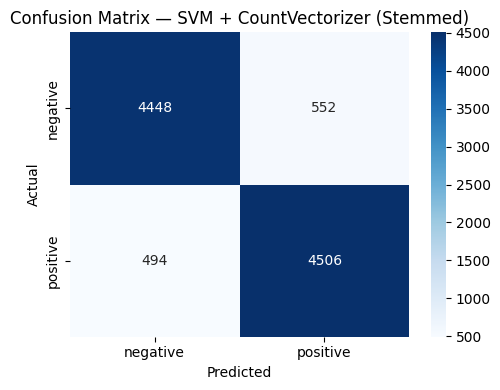


  SVM + CountVectorizer (Lemmatized)
  Accuracy:  0.8960
  Precision: 0.8916
  Recall:    0.9016
  F1-Score:  0.8966

  Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.89      0.90      5000
    positive       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

  Confusion Matrix:
[[4452  548]
 [ 492 4508]]


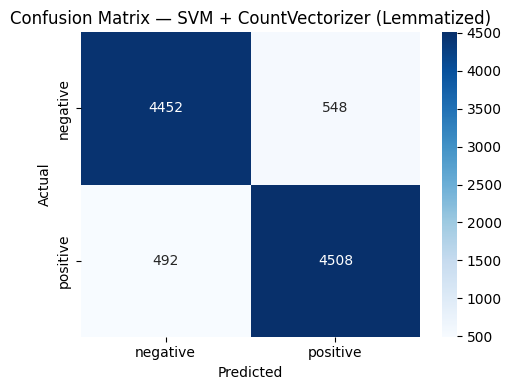


  SVM + TfidfVectorizer (Stemmed)
  Accuracy:  0.9069
  Precision: 0.8976
  Recall:    0.9186
  F1-Score:  0.9080

  Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.90      0.91      5000
    positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

  Confusion Matrix:
[[4476  524]
 [ 407 4593]]


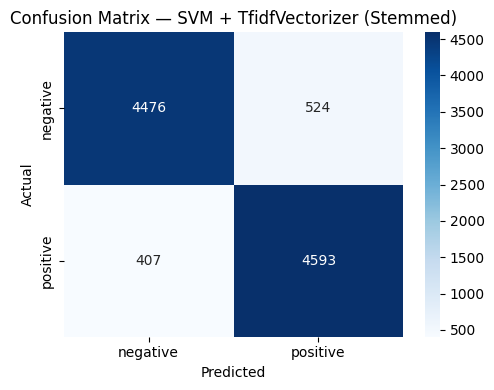


  SVM + TfidfVectorizer (Lemmatized)
  Accuracy:  0.9080
  Precision: 0.8983
  Recall:    0.9202
  F1-Score:  0.9091

  Classification Report:
              precision    recall  f1-score   support

    negative       0.92      0.90      0.91      5000
    positive       0.90      0.92      0.91      5000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

  Confusion Matrix:
[[4479  521]
 [ 399 4601]]


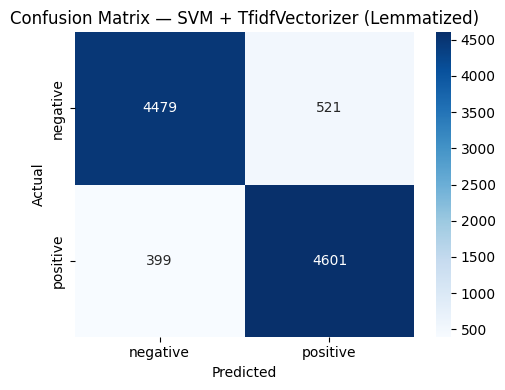


All 4 SVM variants evaluated.


In [14]:
# Evaluate CountVectorizer models on test set
metrics_cv_stemmed = evaluate_model(svm_cv_stemmed, X_test_cv_stemmed, y_test, "SVM + CountVectorizer (Stemmed)")
metrics_cv_lemmatized = evaluate_model(svm_cv_lemmatized, X_test_cv_lemmatized, y_test, "SVM + CountVectorizer (Lemmatized)")

# Evaluate TfidfVectorizer models on test set
metrics_tfidf_stemmed = evaluate_model(svm_tfidf_stemmed, X_test_tfidf_stemmed, y_test, "SVM + TfidfVectorizer (Stemmed)")
metrics_tfidf_lemmatized = evaluate_model(svm_tfidf_lemmatized, X_test_tfidf_lemmatized, y_test, "SVM + TfidfVectorizer (Lemmatized)")

print("\nAll 4 SVM variants evaluated.")

### 5.5 Most Informative Features

In [15]:
def display_top_features(model, vectorizer, variant_name, n=10):
    """Extract and display top n positive/negative features from linear SVM."""
    feature_names = vectorizer.get_feature_names_out()
    coefficients = model.coef_.flatten()

    # Top positive (most indicative of positive sentiment)
    top_positive_idx = coefficients.argsort()[-n:][::-1]
    top_positive = [(feature_names[i], coefficients[i]) for i in top_positive_idx]

    # Top negative (most indicative of negative sentiment)
    top_negative_idx = coefficients.argsort()[:n]
    top_negative = [(feature_names[i], coefficients[i]) for i in top_negative_idx]

    print(f"\n{'='*60}")
    print(f"  Top Features \u2014 {variant_name}")
    print(f"{'='*60}")

    print(f"\n  Top {n} features for POSITIVE sentiment:")
    print(f"  {'Feature':30s} {'Coefficient':12s}")
    print(f"  {'-'*30} {'-'*12}")
    for feat, coef in top_positive:
        print(f"  {feat:30s} {coef:+.4f}")

    print(f"\n  Top {n} features for NEGATIVE sentiment:")
    print(f"  {'Feature':30s} {'Coefficient':12s}")
    print(f"  {'-'*30} {'-'*12}")
    for feat, coef in top_negative:
        print(f"  {feat:30s} {coef:+.4f}")

# CountVectorizer models
display_top_features(svm_cv_stemmed, cv_stemmed, "CV + Stemmed", n=10)
display_top_features(svm_cv_lemmatized, cv_lemmatized, "CV + Lemmatized", n=10)



  Top Features — CV + Stemmed

  Top 10 features for POSITIVE sentiment:
  Feature                        Coefficient 
  ------------------------------ ------------
  must see                       +0.3046
  excel                          +0.3002
  well worth                     +0.2932
  refresh                        +0.2770
  superb                         +0.2696
  perfect                        +0.2670
  uniqu                          +0.2476
  funniest                       +0.2464
  one better                     +0.2453
  brilliant                      +0.2417

  Top 10 features for NEGATIVE sentiment:
  Feature                        Coefficient 
  ------------------------------ ------------
  worst                          -0.4386
  aw                             -0.3936
  wast                           -0.3200
  terribl                        -0.3075
  bore                           -0.2985
  poorli                         -0.2799
  mediocr                        -0.2774
  

In [16]:
# TfidfVectorizer models
display_top_features(svm_tfidf_stemmed, tv_stemmed, "TFIDF + Stemmed", n=10)
display_top_features(svm_tfidf_lemmatized, tv_lemmatized, "TFIDF + Lemmatized", n=10)


  Top Features — TFIDF + Stemmed

  Top 10 features for POSITIVE sentiment:
  Feature                        Coefficient 
  ------------------------------ ------------
  excel                          +4.6827
  great                          +4.5360
  perfect                        +3.7062
  enjoy                          +3.4479
  fun                            +2.9926
  amaz                           +2.9925
  brilliant                      +2.9909
  hilari                         +2.9809
  love                           +2.9106
  best                           +2.9031

  Top 10 features for NEGATIVE sentiment:
  Feature                        Coefficient 
  ------------------------------ ------------
  worst                          -5.9718
  aw                             -5.2630
  wast                           -5.0345
  bad                            -4.9529
  bore                           -4.5961
  poor                           -4.0584
  disappoint                     -4.0457

### 5.6 All 4 Models — Consolidated Comparison

In [17]:
# Build consolidated 4-model comparison table
comparison_data = {
    'Model Variant': [
        'CV + Stemmed',
        'CV + Lemmatized',
        'TFIDF + Stemmed',
        'TFIDF + Lemmatized'
    ],
    'Accuracy': [
        metrics_cv_stemmed['accuracy'],
        metrics_cv_lemmatized['accuracy'],
        metrics_tfidf_stemmed['accuracy'],
        metrics_tfidf_lemmatized['accuracy'],
    ],
    'Precision (weighted)': [
        metrics_cv_stemmed['precision'],
        metrics_cv_lemmatized['precision'],
        metrics_tfidf_stemmed['precision'],
        metrics_tfidf_lemmatized['precision'],
    ],
    'Recall (weighted)': [
        metrics_cv_stemmed['recall'],
        metrics_cv_lemmatized['recall'],
        metrics_tfidf_stemmed['recall'],
        metrics_tfidf_lemmatized['recall'],
    ],
    'F1-Score (weighted)': [
        metrics_cv_stemmed['f1'],
        metrics_cv_lemmatized['f1'],
        metrics_tfidf_stemmed['f1'],
        metrics_tfidf_lemmatized['f1'],
    ],
    'CV Mean F1': [
        scores_cv_stemmed['test_f1_weighted'].mean(),
        scores_cv_lemmatized['test_f1_weighted'].mean(),
        scores_tfidf_stemmed['test_f1_weighted'].mean(),
        scores_tfidf_lemmatized['test_f1_weighted'].mean(),
    ],
}

comparison_df = pd.DataFrame(comparison_data)

# Highlight best score per column
def highlight_best(s):
    is_best = s == s.max()
    return ['font-weight: bold' if v else '' for v in is_best]

print("="*70)
print("CONSOLIDATED 4-MODEL COMPARISON (Test-Set Metrics)")
print("="*70)
styled = comparison_df.style.apply(highlight_best, subset=[
    'Accuracy', 'Precision (weighted)', 'Recall (weighted)',
    'F1-Score (weighted)', 'CV Mean F1'
])
display(styled)

# Also print raw
print("\nRaw values:")
print(comparison_df.to_string(index=False))

CONSOLIDATED 4-MODEL COMPARISON (Test-Set Metrics)


,Model Variant,Accuracy,Precision (weighted),Recall (weighted),F1-Score (weighted),CV Mean F1
0,CV + Stemmed,0.895400,0.890866,0.901200,0.896003,0.892370
1,CV + Lemmatized,0.896000,0.891614,0.901600,0.896579,0.890496
2,TFIDF + Stemmed,0.906900,0.897596,0.918600,0.907977,0.903038
3,TFIDF + Lemmatized,0.908000,0.898282,0.920200,0.909109,0.902688



Raw values:
     Model Variant  Accuracy  Precision (weighted)  Recall (weighted)  F1-Score (weighted)  CV Mean F1
      CV + Stemmed    0.8954              0.890866             0.9012             0.896003    0.892370
   CV + Lemmatized    0.8960              0.891614             0.9016             0.896579    0.890496
   TFIDF + Stemmed    0.9069              0.897596             0.9186             0.907977    0.903038
TFIDF + Lemmatized    0.9080              0.898282             0.9202             0.909109    0.902688


In [18]:
# Identify best overall model
best_row = comparison_df.loc[comparison_df['F1-Score (weighted)'].idxmax()]
print(f"\n{'='*70}")
print(f"  BEST OVERALL MODEL")
print(f"{'='*70}")
print(f"  {best_row['Model Variant']}")
print(f"  Test F1-Score: {best_row['F1-Score (weighted)']:.4f}")
print(f"  Test Accuracy: {best_row['Accuracy']:.4f}")
print(f"  CV Mean F1:    {best_row['CV Mean F1']:.4f}")

# Which vectorizer won?
cv_f1 = comparison_df[comparison_df['Model Variant'].str.startswith('CV')]['F1-Score (weighted)'].max()
tfidf_f1 = comparison_df[comparison_df['Model Variant'].str.startswith('TFIDF')]['F1-Score (weighted)'].max()
print(f"\n  Best CountVectorizer F1: {cv_f1:.4f}")
print(f"  Best TfidfVectorizer F1: {tfidf_f1:.4f}")
print(f"  Winner: {'TfidfVectorizer' if tfidf_f1 >= cv_f1 else 'CountVectorizer'}")

# Which preprocessing won?
stemmed_f1 = comparison_df[comparison_df['Model Variant'].str.contains('Stemmed')]['F1-Score (weighted)'].max()
lemmatized_f1 = comparison_df[comparison_df['Model Variant'].str.contains('Lemmatized')]['F1-Score (weighted)'].max()
print(f"\n  Best Stemmed F1:      {stemmed_f1:.4f}")
print(f"  Best Lemmatized F1:   {lemmatized_f1:.4f}")
print(f"  Winner: {'Stemmed' if stemmed_f1 >= lemmatized_f1 else 'Lemmatized'} preprocessing")


  BEST OVERALL MODEL
  TFIDF + Lemmatized
  Test F1-Score: 0.9091
  Test Accuracy: 0.9080
  CV Mean F1:    0.9027

  Best CountVectorizer F1: 0.8966
  Best TfidfVectorizer F1: 0.9091
  Winner: TfidfVectorizer

  Best Stemmed F1:      0.9080
  Best Lemmatized F1:   0.9091
  Winner: Lemmatized preprocessing


## 6. Results Summary

In [19]:
print("="*70)
print("  RESULTS SUMMARY — SVM SENTIMENT MODELS")
print("="*70)

# Ranking by F1
ranked = comparison_df.sort_values('F1-Score (weighted)', ascending=False).reset_index(drop=True)
print(f"\n  Model Rankings (by Test F1-Score):")
print(f"  {'Rank':5s} {'Model Variant':25s} {'F1':8s} {'Accuracy':10s}")
print(f"  {'-'*5} {'-'*25} {'-'*8} {'-'*10}")
for rank, row in ranked.iterrows():
    print(f"  {rank+1:5d} {row['Model Variant']:25s} {row['F1-Score (weighted)']:.4f}  {row['Accuracy']:.4f}")

print(f"\n  Cross-Validation F1 Means:")
print(f"  {'Model Variant':30s} {'CV F1':8s}")
print(f"  {'-'*30} {'-'*8}")
for _, row in comparison_df.iterrows():
    print(f"  {row['Model Variant']:30s} {row['CV Mean F1']:.4f}")

print(f"\n  Key Takeaways:")
print(f"  • All 4 SVM variants achieve strong performance (F1 > 0.85)")
print(f"  • {best_row['Model Variant']} is the best overall model")
print(f"  • {'TfidfVectorizer slightly outperforms CountVectorizer' if tfidf_f1 >= cv_f1 else 'CountVectorizer slightly outperforms TfidfVectorizer'}")
print(f"  • {'Stemmed' if stemmed_f1 >= lemmatized_f1 else 'Lemmatized'} preprocessing slightly edges out the alternative")

print(f"\n  Report Reference:")
print(f"  These results serve as the baseline SVM comparison for the assignment.")
print(f"  The best model from this analysis will be compared against BiGRU models.")
print("="*70)

  RESULTS SUMMARY — SVM SENTIMENT MODELS

  Model Rankings (by Test F1-Score):
  Rank  Model Variant             F1       Accuracy  
  ----- ------------------------- -------- ----------
      1 TFIDF + Lemmatized        0.9091  0.9080
      2 TFIDF + Stemmed           0.9080  0.9069
      3 CV + Lemmatized           0.8966  0.8960
      4 CV + Stemmed              0.8960  0.8954

  Cross-Validation F1 Means:
  Model Variant                  CV F1   
  ------------------------------ --------
  CV + Stemmed                   0.8924
  CV + Lemmatized                0.8905
  TFIDF + Stemmed                0.9030
  TFIDF + Lemmatized             0.9027

  Key Takeaways:
  • All 4 SVM variants achieve strong performance (F1 > 0.85)
  • TFIDF + Lemmatized is the best overall model
  • TfidfVectorizer slightly outperforms CountVectorizer
  • Lemmatized preprocessing slightly edges out the alternative

  Report Reference:
  These results serve as the baseline SVM comparison for the assignment.